# Automated Beamline Alignment at ALS 5.3.1
khchan@lbl.gov, xchong@lbl.gov, awojdyla@lbl.gov; Nov 2025

We would like to reuse the imitial version of blop at ALS 5.3.1

We want to show that we can switch between a real beamline (EPICS over ophyd) and a virtual beamline (shadow over ophyd)

one issue is tha shadow doesn't install on python>3.9, so we'll have to make a server.

Following https://nsls-ii.github.io/blop/

blop.__version__ == 0.5.1.dev74

In [1]:
# environment: blop 
import blop 

# files of interest are here:
#~/.ipython/profile_blop/startup


## Configure blop

In [2]:
blop.__version__

'0.5.1.dev74'

### define degrees of freedom (20-motors)

In [3]:
import ophyd
from ophyd import EpicsMotor, EpicsSignal
ophyd.set_cl('caproto')

m101_pitch = EpicsMotor('bl531_esp300:m101_pitch_mm', name='m101_pitch')
m101_bend  = EpicsMotor('bl531_esp300:m101_bend_um', name='m101_bend')
mono_height = EpicsMotor('bl531_xps1:mono_height_mm', name='mono_height')
mono_angle = EpicsMotor('bl531_xps1:mono_angle_deg', name='mono_angle')
mono_angle.wait_for_connection(timeout=2.0)
mono_angle.read()
mono_angle.settle_time = 2

### define detectors (21-detectors)

In [4]:
beamstop = ophyd.EpicsSignal('bl201-beamstop:current', name='beamstop')
camera = ophyd.EpicsSignal('BL531a2A2448:image1:ArrayData', name='camera')

# author: tmorris@bnl.gov
# June 2023
# as used at ALS

# from datetime import datetime
# import matplotlib.pyplot as plt

# import bluesky.plans as bp
# from bluesky.callbacks import best_effort
# from bluesky.run_engine import RunEngine
# from databroker import Broker
# from ophyd.utils import make_dir_tree

# import ophyd_basler
# from ophyd_basler.basler_handler import BaslerCamHDF5Handler
# from ophyd_basler.basler_camera import BaslerCamera

# ophyd_basler.available_devices()

# #cam num sets the camera we use 
# basler_cam = BaslerCamera(cam_num=3, verbose=True, name="basler_cam")
# basler_cam.exposure_time.put(400)

# import bluesky
# from bluesky import RunEngine
# RE = RunEngine({})

# db = Broker.named("temp")
# db.reg.register_handler("BASLER_CAM_HDF5", BaslerCamHDF5Handler, overwrite=True)


# bec = best_effort.BestEffortCallback()
# bec.disable_plots()
# RE.subscribe(bec)
# RE.subscribe(db.insert)

# root_dir = "/tmp/basler"
# _ = make_dir_tree(datetime.now().year, base_path=root_dir)

### define degrees of freedom (20-motors)

In [5]:
from blop import DOF
# DOF(device=m101_bend, description="toroid bend",  units="mm", limits=(0, 1)),
dofs = [
    DOF(device=m101_bend, search_domain=(-1000,0)),
    DOF(device=m101_pitch, search_domain=(-0.7,-0.3)),
]
    # DOF(movable=m101_bend,  type="continuous", search_domain=(-1000, 0)),
    # DOF(movable=m101_pitch, type="continuous", search_domain=(-0.8, -0.2)),
# 'm101_pitch'
# 'm101_bend'
# 'mono_height'
# 'mono_angle'

### define objective function

In [6]:
import numpy as np
import scipy as sp

def get_beam_stats(im):

    fim = sp.ndimage.median_filter(im, size=5)

    threshold = 0.5 * (fim.min() + fim.max())

    mask = fim > threshold

    total = fim[mask].sum()

    ny, nx = fim.shape

    x, y = np.arange(nx), np.arange(ny)
    X, Y = np.meshgrid(x, y)

    x_mean = np.sum(mask * X) / mask.sum()
    y_mean = np.sum(mask * Y) / mask.sum()

    x_width =  np.sqrt(np.sum(mask * np.square(X - x_mean)) / mask.sum())
    y_width =  np.sqrt(np.sum(mask * np.square(Y - y_mean)) / mask.sum())

    return (fim.max() - fim.min()), x_mean, y_mean, x_width, y_width, total

In [7]:
from blop import Objective

#objectives = [Objective(name="beamsize", description="rms beam size", target="min")]
objectives = [Objective(name="power density", description="power density", target="max")]

### define dataprocessing (metrics/"digestion")

In [8]:
from ophyd import Device, EpicsSignal, Signal, Component as Cpt

import epics
from time import sleep



# class BeamStopCurrent(Device):
#     prec = Cpt(EpicsSignal, ".PREC")
#     current = Cpt(EpicsSignal, "")

# beamstop_current_device = BeamStopCurrent("bl201-beamstop:current", name="beamstop")
# beamstop_current_device.prec.put(3)  # This is needed for LiveTable (via BestEffortCallback) to print the values with proper number of decimal values
# beamstop_current = beamstop_current_device.current
# beamstop_current.kind = "hinted"


# import ophyd
# from PIL import Image
# import scipy as sp
# import epics

# class SAXSDetector(Device):
#     image = Cpt(Signal, kind="normal")
#     profile = Cpt(Signal, kind="normal")
#     filename = Cpt(Signal, kind="normal")

#     def __init__(
#         self,
#         center,
#         *args,
#         **kwargs,
#     ):
#         """
#         A class to instantiate a Basler ophyd object.
#         """
#         super().__init__(*args, **kwargs)

#         self.center = center

#     def trigger(self):

#         epics.caput("13PIL1:cam1:Acquire", 1)

#         ttime.sleep(3)

#         filename_ascii = epics.caget('13PIL1:cam1:FullFileName_RBV')
#         self.filename.put(bytes(filename_ascii).decode()[:-1])

#         image = np.array(Image.open(self.filename.get())).clip(max=1e3)
#         self.image.put(image)

#         ny, nx = image.shape
#         x, y = np.arange(nx), np.arange(ny)
#         X, Y = np.meshgrid(x, y)
#         Z = (X - self.center[0]) + 1j * (Y - self.center[1])
#         R = np.abs(Z)

#         bins = np.linspace(0, 500, 256)

#         mask = image > -1

#         profile = sp.stats.binned_statistic(R[mask], image[mask], statistic="mean", bins=bins).statistic

#         self.profile.put(profile)

#         super().trigger()

#         return NullStatus()

#     def stage(self):
#         super().stage()
        
#     def unstage(self):
#         super().unstage()

class Basler_Cam(Device):
    image = Cpt(Signal, kind="normal")
    profile = Cpt(Signal, kind="normal")
    filename = Cpt(Signal, kind="normal")

    def __init__(
        self,
        *args,
        **kwargs,
    ):
        """
        A class to instantiate a Basler ophyd object.
        """
        super().__init__(*args, **kwargs)


    def trigger(self):

        epics.caput("BL531a2A2448:cam1:Acquire", 1)

        sleep(0.5)

        # filename_ascii = epics.caget('13PIL1:cam1:FullFileName_RBV')
        # self.filename.put(bytes(filename_ascii).decode()[:-1])

        img = epics.caget("BL531a2A2448:image1:ArrayData")
        img = img.reshape((2048,512,3)).sum(axis=2)

        #image = np.array(Image.open(self.filename.get())).clip(max=1e3)
        self.image.put(img)

        super().trigger()

        #return NullStatus()
        return img

    def stage(self):
        super().stage()
    
    def unstage(self):
        super().unstage()

basler_cam = Basler_Cam(name="basler_cam")

In [9]:
#basler_cam = Basler_Cam(name="basler_cam")
img = basler_cam.trigger()
get_beam_stats(img)

(79,
 287.1919953596288,
 702.8277262180975,
 53.556697679376796,
 6.6961669043137135,
 190767)

#### from 93-digestion

In [10]:
import epics
from time import sleep

# from https://nsls-ii.github.io/blop/tutorials/introduction.html
def digestion(df):
    for index, entry in df.iterrows():
        img = basler_cam.trigger()  # this is needed to trigger the camera to acquire the image and make it available for reading out
        (range, x_mean, y_mean, x_width, y_width, total) = get_beam_stats(img)
        df.loc[index, "beamsize"] = x_width * y_width
        df.loc[index, "flux"] = total
        df.loc[index, "power density"] = total/(x_width * y_width)
        print(f"index: {index}, beamsize: {x_width * y_width}, flux: {total}, power density: {total/(x_width * y_width)}")
    return df

#### from 93-optimization

In [11]:
# from bloptools.bayesian import Agent, DOF, Objective

# dofs = [
#     DOF(device=m101_pitch, description="toroid pitch", units="mm", limits=(0, 1)),
#     DOF(device=m101_bend, description="toroid bend",  units="mm", limits=(0, 1)),
#     DOF(device=mono_height, description="monochromator height", units="mm", limits=(0, 1)),
# ]


# objectives = [
#     Objective(key="beam_max", description="beam flux", target="max", log=True),
#     Objective(key="beam_fwhm_x", description="beam width", target="min", log=True),
#     Objective(key="beam_fwhm_y", description="beam height", target="min", log=True),
# ]

# agent = Agent(
#     dofs=dofs,
#     objectives=objectives,
#     digestion=beam_digestion,
#     db=db,
# )


## Start runengine and blop agent

In [12]:
#from blop.utils import prepare_re_env
# %run -i $prepare_re_env.__file__ --db-type=temp
# -> look here: /home/bl531/miniconda3/envs/blop_shadow/lib/python3.1/site-packages/blop/utils

import bluesky.plans as bp
from bluesky.callbacks import best_effort
from bluesky.run_engine import RunEngine
from databroker import Broker


RE = RunEngine({})
bec = best_effort.BestEffortCallback()
RE.subscribe(bec)

# db = Broker.named(db_type)
# try:
#     databroker.assets.utils.install_sentinels(db.reg.config, version=1)
# except Exception:
#     pass
# RE.subscribe(db.insert)


from databroker import Broker
db = Broker.named('temp')

# Insert all metadata/data captured into db.
RE.subscribe(db.insert)


1

In [13]:
from blop import Agent

agent = Agent(
    dofs=dofs,
    objectives=objectives,
    digestion=digestion,
    db=db,
)

### initialize the agent

In [14]:
objectives

[Objective(name='power density', description='power density', type='continuous', target='max', transform=None, weight=1.0, active=True, trust_domain=None, min_noise=1e-06, max_noise=1.0, units=None, latent_groups=[])]

In [15]:
RE(agent.learn("quasi-random", n=16))




Transient Scan ID: 1     Time: 2026-02-24 11:59:10
Persistent Unique Scan ID: '4cb03bfe-9b6d-4f86-b802-59ebbbd3bcb9'
New stream: 'primary'
+-----------+------------+------------+------------+
|   seq_num |       time |  m101_bend | m101_pitch |
+-----------+------------+------------+------------+
|         1 | 11:59:16.2 | -568.37889 |   -0.63968 |
|         2 | 11:59:23.3 | -909.91407 |   -0.69072 |
|         3 | 11:59:29.2 | -868.45005 |   -0.55374 |
|         4 | 11:59:35.5 | -652.85877 |   -0.50170 |
|         5 | 11:59:40.1 | -548.52138 |   -0.46564 |
|         6 | 11:59:45.6 | -421.18305 |   -0.57885 |
|         7 | 11:59:50.6 | -365.01789 |   -0.66568 |
|         8 | 11:59:56.9 | -140.67048 |   -0.61486 |
|         9 | 12:00:02.4 |  -72.77907 |   -0.52665 |
|        10 | 12:00:08.3 | -226.23156 |   -0.49049 |
|        11 | 12:00:13.5 | -252.37116 |   -0.44155 |
|        12 | 12:00:19.0 |  -59.76015 |   -0.35248 |
|        13 | 12:00:26.4 | -461.82822 |   -0.30452 |
|        14

('4cb03bfe-9b6d-4f86-b802-59ebbbd3bcb9',)

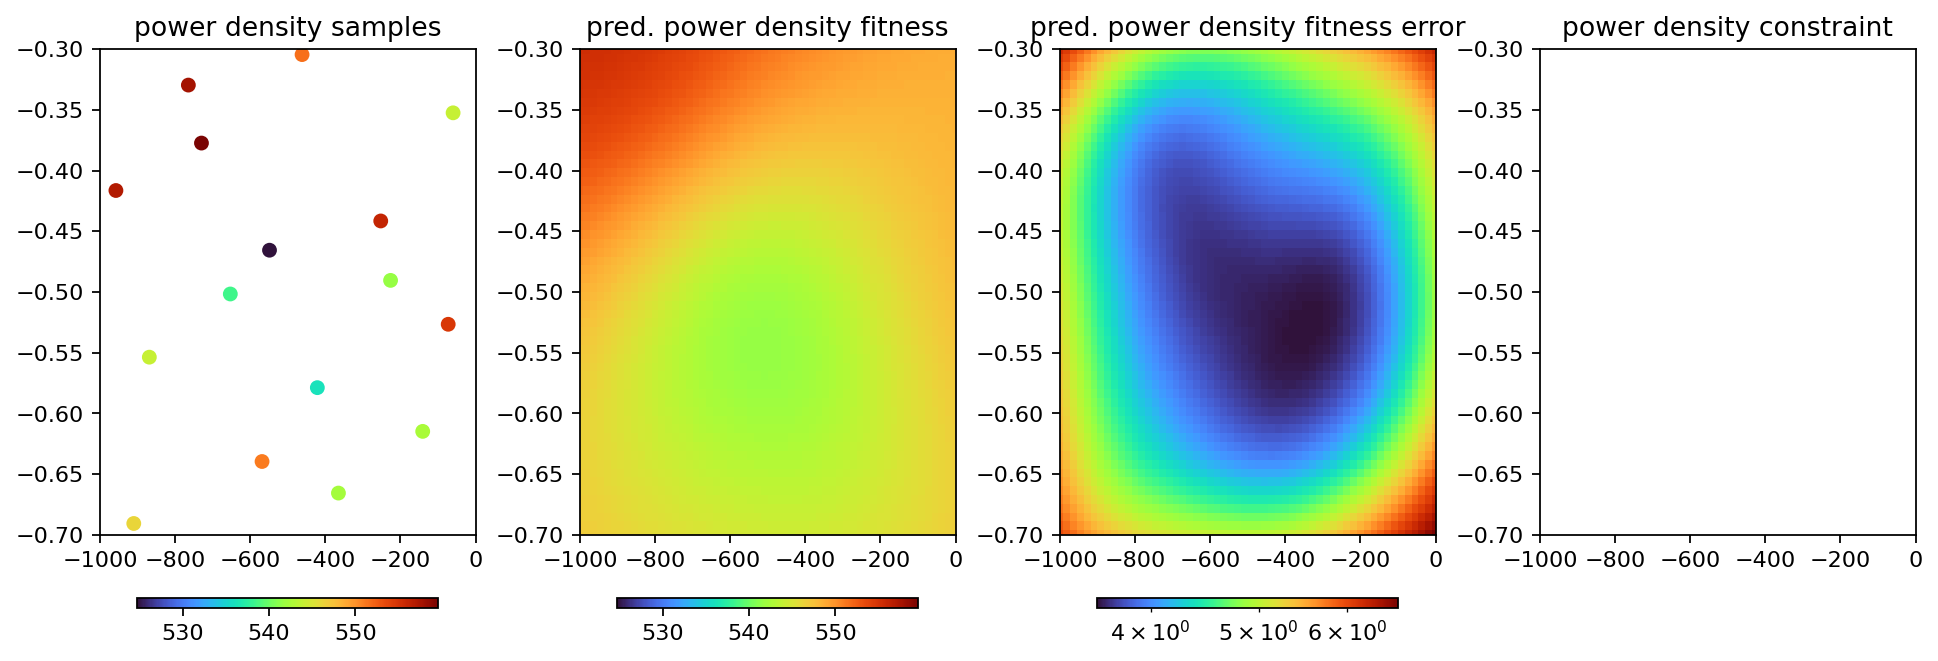

CA.Client.Exception...............................................
    Context: "192.168.10.124:46851"
    Source File: ../cac.cpp line 1237
    Current Time: Tue Feb 24 2026 13:27:09.183636301
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:46345"
    Source File: ../cac.cpp line 1237
    Current Time: Tue Feb 24 2026 15:44:30.004334483
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:43611"
    Source File: ../cac.cpp line 1237
    Current Time: Wed Feb 25 2026 08:18:17.387858262
..................................................................
CA.Client.Exception...............................................
    Context: "192.168.10.124:33611"
    Source File: ../cac.cpp line 1237
    Current Time: Wed Feb 25 2026 08:19:11.793365248
.......................

In [22]:
agent.plot_objectives()

In [17]:
# agent.all_acq_funcs
agent.all_acqfs #new

,identifier,type,multitask_only,description
name,,,,
expected_improvement,ei,analytic,False,"The expected value of max(f(x) - \nu, 0), wher..."
expected_mean,em,analytic,False,The expected value at each input.
noisy_expected_hypervolume_improvement,nehvi,analytic,True,It's like a big box. How big is the box?
probability_of_improvement,pi,analytic,False,The probability that this input improves on th...
upper_confidence_bound,ucb,analytic,False,"The expected value, plus some multiple of the ..."
lower_bound_max_value_entropy,lbmve,monte_carlo,False,"Max entropy search, basically"
monte_carlo_expected_improvement,qei,monte_carlo,False,"The expected value of max(f(x) - \nu, 0), wher..."
monte_carlo_expected_mean,qem,monte_carlo,False,The expected value at each input.
monte_carlo_noisy_expected_hypervolume_improvement,qnehvi,monte_carlo,True,It's like a big box. How big is the box?


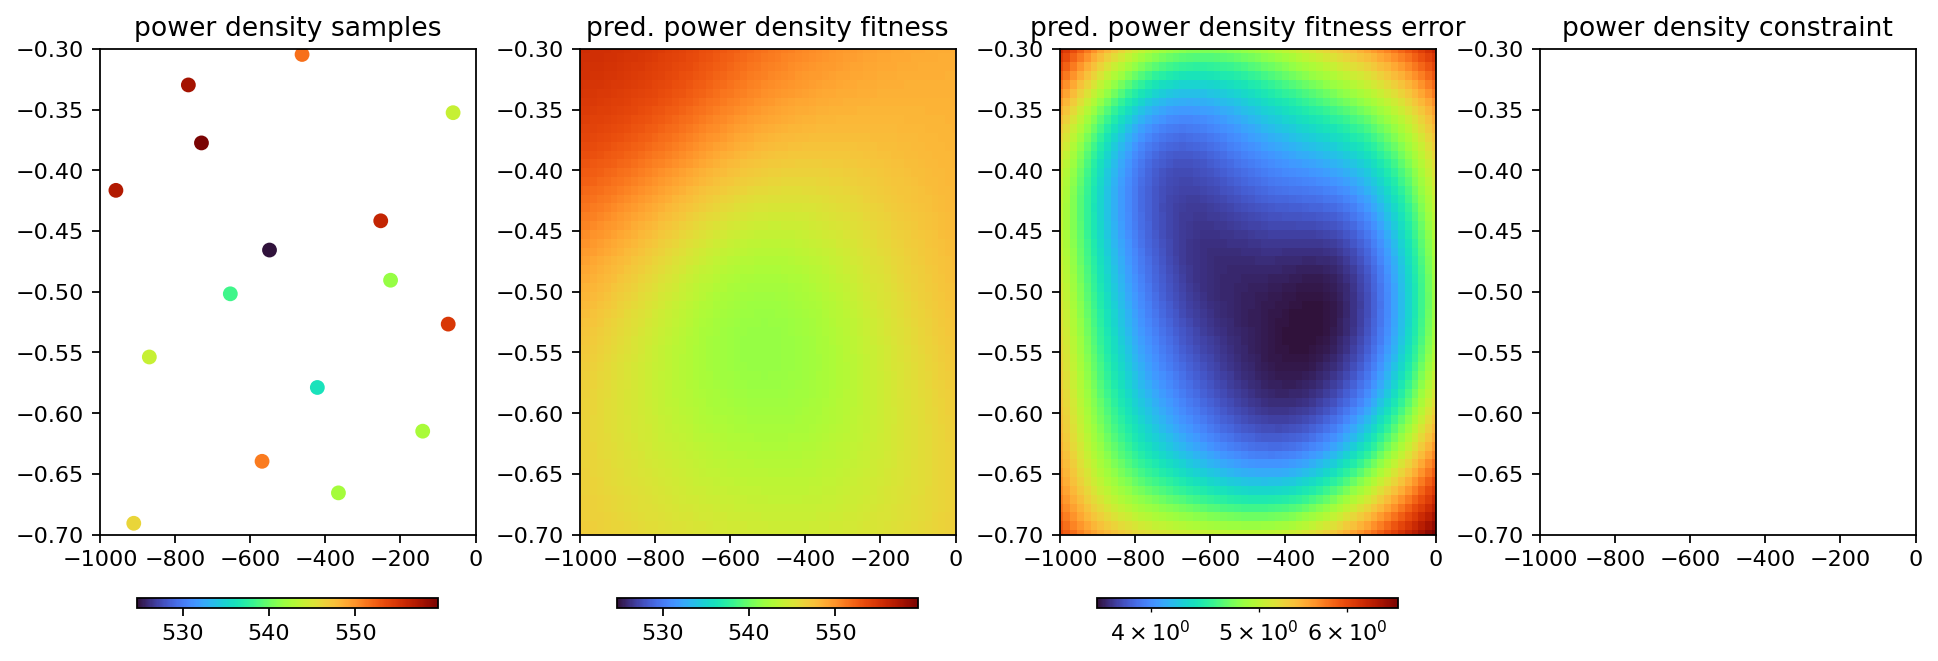

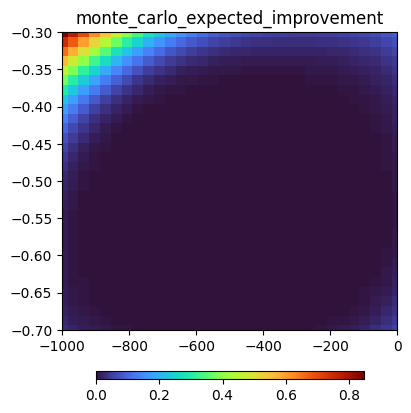

In [18]:
%matplotlib inline
#agent.plot_acquisition(acq_func="qei")
agent.plot_acquisition(acqf="qei") # new

In [19]:
agent.ask("qei", n=1)

{'points': {'m101_bend': [-1000.0], 'm101_pitch': [-0.3]},
 'acqf_name': 'monte_carlo_expected_improvement',
 'acqf_obj': [0.8443365148416431],
 'acqf_kwargs': {'best_f': 559.8892442039717},
 'duration_ms': 49.9689094722271,
 'sequential': True,
 'upsample': 1,
 'read_only_values': array([], shape=(1, 0), dtype=float64)}

In [21]:
# res = agent.ask("qei", n=8, route=True)
# agent.plot_acquisition(acq_func="qei")
# plt.scatter(*res["points"].T, marker="d", facecolor="w", edgecolor="k")
# plt.plot(
#     *res["points"].T,
#     color="r",
# )
# new
# res = agent.ask("qei", n=8, route=True)
# agent.plot_acquisition(acqf="qei")
# plt.scatter(res["points"]["x_rot"], res["points"]["y_rot"], marker="d", facecolor="w", edgecolor="k")
# plt.plot(res["points"]["x_rot"], res["points"]["y_rot"], color="r")
# plt.show()

In [ ]:
RE(agent.learn("qei", n=4, iterations=8))

In [ ]:
agent.plot_objectives()
print(agent.best)

In [ ]:
# Fixed agent.train_targets()[obj.name].numpy() in 

# File ~/src/blop/src/blop/plotting.py:36, in _plot_fitness_objs_one_dof(agent, size, lw)
#      33 test_model_inputs = agent.dofs(active=True).transform(test_inputs)
#      35 for obj_index, obj in enumerate(fitness_objs):
# ---> 36     obj_values = agent.train_targets()(obj.name).numpy()

In [ ]:
agent.train_targets()['beamsize']